<a href="https://colab.research.google.com/github/Luizalima3/Migra-ao/blob/main/C%C3%B3pia_de_topicos_especiais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# CÉLULA 1: EXTRAÇÃO DE DADOS PRIMÁRIOS
# Objetivo: Capturar a tabela HTML diretamente do Portal da Transparência da CMJP
# ==============================================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

# 1. Requisição e extração de tabelas na página da CMJP
url_pagina = "https://joaopessoa.pb.leg.br/transparencia/verbas-indenizatorias/"
tabelas = pd.read_html(url_pagina)

# 2. Selecão da primeira tabela encontrada na página web
df_bruto = tabelas[0]

# 3. GERAÇÃO DO ARQUIVO CSV DOS DADOS BRUTOS
df_bruto.to_csv('cmjp_bruto_integrado.csv', index=False)

# Inspeção inicial dos dados brutos capturados
print("=== DADOS BRUTOS CARREGADOS E SALVOS EM CSV ===")
print(f"Total de registros capturados: {len(df_bruto)}")
df_bruto.head()

=== DADOS BRUTOS CARREGADOS E SALVOS EM CSV ===
Total de registros capturados: 1027


,MÊS/ANO,PARLAMENTAR,SERVIÇO,VALOR,CONTRATOS,NOTAS
0,06/2026,JOSÉ FREIRE DA COSTA,DIVULGAÇÃO DE ATIVIDADE PARLAMENTAR,"R$ 14.000,00",NaN,NaN
1,06/2026,VALDIR JOSÉ DOWSLEY,"ASSESSORIA E CONSULTORIA JURÍDICA, LOCAÇÃO DE ...","R$ 14.000,00",NaN,NaN
2,06/2026,WAMBERTO RAMOS ULYSSES DE CARVALHO,"ASSESSORIA JURÍDICA, ASSESSORIA EM COMUNICAÇÃO...","R$ 14.000,00",NaN,NaN
3,06/2026,ROMULO LOPES DANTAS COELHO,"ASSESSORIAS JURÍDICA, MARKETING E COMUNICAÇÃO","R$ 14.000,00",NaN,NaN
4,06/2026,REBECA SODRÉ DE MELO DA FONSECA FIGUEIREDO,CONSULTORIA JURÍDICA E CONSULTORIA CONTÁBIL,"R$ 9.333,33",NaN,NaN


In [ ]:
# ==============================================================================
# CÉLULA 2: LIMPEZA PRIMÁRIA E FILTRAGEM TEMPORAL
# Objetivo: Remover ruídos (colunas nulas), converter textos monetários
# para valores numéricos, padronizar nomes de vereadores e filtrar a legislatura.
# ==============================================================================

# 1. Eliminar colunas irrelevantes para o modelo (compostas por nulos e ícones de PDFs)
df = df_bruto.drop(columns=['CONTRATOS', 'NOTAS'], errors='ignore')

# 2. Imputação de valores ausentes na descrição do serviço para evitar perda de linhas
df['SERVIÇO'] = df['SERVIÇO'].fillna('OUTROS')

# 3. Tratamento e conversão da coluna VALOR (Texto "R$ 14.000,00" -> Float 14000.00)
df['VALOR_LIMPO'] = (
    df['VALOR']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
    .astype(float)
)

# 4. Padronização textual do nome do parlamentar (caixa alta e remoção de espaços nas pontas)
df['PARLAMENTAR'] = df['PARLAMENTAR'].str.upper().str.strip()

# 5. Extração do ano (últimos 4 dígitos da string 'MM/AAAA') e filtragem da legislatura (2021-2024)
df['ANO'] = df['MÊS/ANO'].astype(str).str[-4:].astype(int)
df_filtrado = df[(df['ANO'] >= 2021) & (df['ANO'] <= 2024)].copy()

# Validação do resultado da limpeza
print("=== LIMPEZA E FILTRAGEM CONCLUÍDAS ===")
print("Anos mantidos no dataset:", sorted(df_filtrado['ANO'].unique()))
print("Total de transações válidas:", len(df_filtrado))
print("Quantidade de parlamentares identificados:", df_filtrado['PARLAMENTAR'].nunique())
df_filtrado.head()

=== LIMPEZA E FILTRAGEM CONCLUÍDAS ===
Anos mantidos no dataset: [np.int64(2022), np.int64(2023), np.int64(2024)]
Total de transações válidas: 521
Quantidade de parlamentares identificados: 31


,MÊS/ANO,PARLAMENTAR,SERVIÇO,VALOR,VALOR_LIMPO,ANO
506,12/2024,VALDIR JOSÉ DOWSLEY,ASSESSORIA JURÍDICA,"R$ 4.500,00",4500.00,2024
507,12/2024,PAULO TARCÍSIO PESSOA JARDIM,ASSESSORIA JURÍDICA,"R$ 2.200,00",2200.00,2024
508,12/2024,RONIVON RAMALHO DINIZ,ASSESSORIA JURÍDICA E ASSESSORIA CONTÁBIL,"R$ 2.935,48",2935.48,2024
509,12/2024,RENATO MARTINS LEITÃO,ASSESSORIA JURÍDICA,"R$ 7.000,00",7000.00,2024
510,12/2024,MARMUTHE DE SOUZA CAVALCANTI,ASSESSORIA JURÍDICA E ALUGUEL DE SALA,"R$ 7.000,00",7000.00,2024


In [ ]:
# ==============================================================================
# CÉLULA 3: ENGENHARIA DE FEATURES (AGREGAÇÃO POR PARLAMENTAR)
# Objetivo: Mudar a unidade de análise de 'recibos mensais' para 'vereador',
# calculando os totais, ticket médio e as proporções percentuais (%) de gastos.
# ==============================================================================

# 1. Função para discretizar e consolidar descrições de serviços em 5 categorias funcionais
def mapear_categoria(servico):
    servico = str(servico).upper()
    if 'DIVULGAÇÃO' in servico or 'DIVULGACAO' in servico or \
       'MARKETING' in servico or 'PUBLICIDADE' in servico or \
       'MÍDIAS' in servico or 'MIDIAS' in servico or 'MÍDIA' in servico or 'MIDIA' in servico or \
       'DESIGNER' in servico or 'COMUNICAÇÃO' in servico or 'COMUNICACAO' in servico or \
       'DIGITAL' in servico or 'IMPRENSA' in servico or 'DAP' in servico:
        return 'DIVULGACAO_MARKETING'
    elif 'JURÍDICA' in servico or 'JURIDICA' in servico:
        return 'CONSULTORIA_JURIDICA'
    elif 'CONTÁBIL' in servico or 'CONTABIL' in servico:
        return 'CONSULTORIA_CONTABIL'
    elif 'LOCAÇÃO' in servico or 'LOCACAO' in servico or 'VEÍCULO' in servico or 'VEICULO' in servico or 'ALUGUEL' in servico:
      return 'LOCACAO_ALUGUEIS'
    else:
        return 'OUTROS'

# Aplicar a categorização ao dataframe filtrado
df_filtrado['CATEGORIA'] = df_filtrado['SERVIÇO'].apply(mapear_categoria)

# 2. Criar Features Absolutas (Total Gasto, Qtd de Notas e Valor Médio por Nota)
df_totais = df_filtrado.groupby('PARLAMENTAR').agg(
    TOTAL_GASTO=('VALOR_LIMPO', 'sum'),
    QTD_NOTAS=('VALOR_LIMPO', 'count'),
    VALOR_MEDIO_NOTA=('VALOR_LIMPO', 'mean')
).reset_index()

# ------------------------------------------------------------------------------
#CÁLCULO DA SAZONALIDADE / DISTRIBUIÇÃO TEMPORAL MENSAL
# ------------------------------------------------------------------------------
df_mensal = df_filtrado.groupby(['PARLAMENTAR', 'MÊS/ANO'])['VALOR_LIMPO'].sum().reset_index()
df_sazonalidade = df_mensal.groupby('PARLAMENTAR').agg(
    DESVIO_MENSAL=('VALOR_LIMPO', 'std')
).reset_index()
df_sazonalidade['DESVIO_MENSAL'] = df_sazonalidade['DESVIO_MENSAL'].fillna(0)
# ------------------------------------------------------------------------------

# 3. Criar Features Relativas (Proporção % do teto gasto em cada categoria)
df_pivot = df_filtrado.pivot_table(
    index='PARLAMENTAR',
    columns='CATEGORIA',
    values='VALOR_LIMPO',
    aggfunc='sum',
    fill_value=0
)
df_perc = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100

# 4. Unir tabelas para compor o dataset consolidado final (Totais + Sazonalidade + Porcentagens)
df_consolidado = pd.merge(df_totais, df_sazonalidade, on='PARLAMENTAR').merge(df_perc, on='PARLAMENTAR')

print("=== AGREGAÇÃO CONCLUÍDA ===")
print(f"Dimensões da matriz final de parlamentares: {df_consolidado.shape}")
pd.options.display.float_format = '{:.2f}'.format
df_consolidado.head()

=== AGREGAÇÃO CONCLUÍDA ===
Dimensões da matriz final de parlamentares: (31, 10)


,PARLAMENTAR,TOTAL_GASTO,QTD_NOTAS,VALOR_MEDIO_NOTA,DESVIO_MENSAL,CONSULTORIA_CONTABIL,CONSULTORIA_JURIDICA,DIVULGACAO_MARKETING,LOCACAO_ALUGUEIS,OUTROS
0,ANTÔNIO LUIZ DE LIMA FILHO,168000.00,24,7000.00,0.00,0.00,100.00,0.00,0.00,0.00
1,BRUNO FARIAS DE PAIVA,106500.00,23,4630.43,2306.24,0.00,0.00,100.00,0.00,0.00
2,CARLOS GUSTAVO GOMES DE OLIVEIRA,141670.30,22,6439.56,965.77,0.00,0.00,100.00,0.00,0.00
3,CARLOS HENRIQUE DA COSTA SANTOS,109500.00,16,6843.75,625.00,0.00,48.86,51.14,0.00,0.00
4,DAMÁSIO FRANCA SEGUNDO NETO,126600.00,20,6330.00,1687.45,0.00,100.00,0.00,0.00,0.00


In [ ]:
# ==============================================================================
# CÉLULA 4: PRÉ-PROCESSAMENTO, ESCALONAMENTO E EXPORTAÇÃO
# Objetivo: Padronizar variáveis em escalas distintas (R$ vs. %) utilizando
# RobustScaler para tratar outliers, e salvar o dataset pronto.
# ==============================================================================

# 1. Isolar as colunas numéricas (features) removendo o identificador textual
X_features = df_consolidado.drop(columns=['PARLAMENTAR'])

# 2. Aplicar o RobustScaler (baseado na Mediana e no Intervalo Interquartil - IQR)
# Escolha técnica: impede que outliers em reais achatem as variáveis percentuais
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_features)

# 3. Salvar o dataset consolidado em arquivo CSV para ser consumido na etapa de ML
df_consolidado.to_csv('cmjp_features_consolidadas.csv', index=False)

print("=== DATASET TRATADO - CONCLUÍDO COM SUCESSO ===")
print("1. Arquivo 'cmjp_features_consolidadas.csv' gerado no diretório.")
print(f"2. Matriz reescalonada 'X_scaled' pronta para K-Means. Formato: {X_scaled.shape}")

=== DATASET TRATADO - CONCLUÍDO COM SUCESSO ===
1. Arquivo 'cmjp_features_consolidadas.csv' gerado no diretório.
2. Matriz reescalonada 'X_scaled' pronta para K-Means. Formato: (31, 9)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultados = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    inercia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)

    resultados.append({
        'K': k,
        'Inercia': inercia,
        'Silhouette': silhouette
    })

resultados

[{'K': 2,
  'Inercia': 9843.831094825473,
  'Silhouette': np.float64(0.9197657708650809)},
 {'K': 3,
  'Inercia': 187.6770956830582,
  'Silhouette': np.float64(0.9416752505556062)},
 {'K': 4,
  'Inercia': 71.39776604998212,
  'Silhouette': np.float64(0.7720050743049977)},
 {'K': 5,
  'Inercia': 41.91944181737139,
  'Silhouette': np.float64(0.4253316654595529)},
 {'K': 6,
  'Inercia': 33.06235539156362,
  'Silhouette': np.float64(0.3566974832051464)},
 {'K': 7,
  'Inercia': 26.19282356181048,
  'Silhouette': np.float64(0.3828281021734969)},
 {'K': 8,
  'Inercia': 19.922572732869522,
  'Silhouette': np.float64(0.4418218129976952)}]

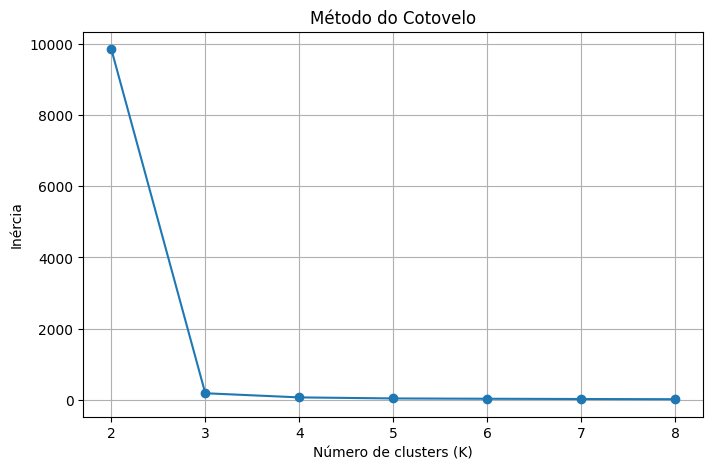

In [ ]:
import matplotlib.pyplot as plt

ks = [r['K'] for r in resultados]
inercia = [r['Inercia'] for r in resultados]

plt.figure(figsize=(8, 5))
plt.plot(ks, inercia, marker='o')

plt.xlabel('Número de clusters (K)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.xticks(ks)
plt.grid(True)

plt.show()

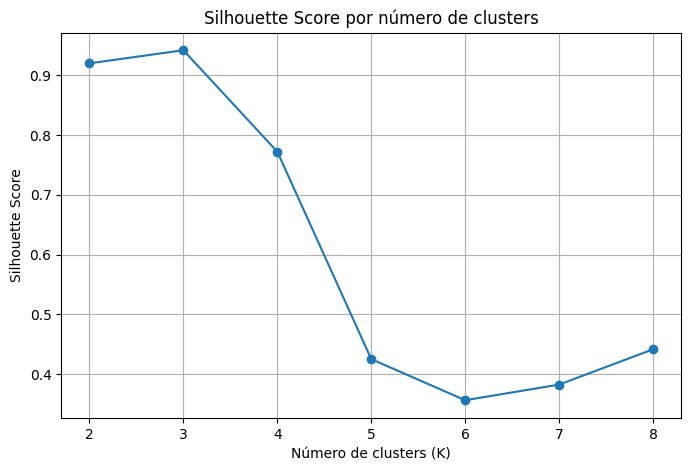

In [ ]:
ks = [r['K'] for r in resultados]
silhouette = [r['Silhouette'] for r in resultados]

plt.figure(figsize=(8, 5))
plt.plot(ks, silhouette, marker='o')

plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por número de clusters')
plt.xticks(ks)
plt.grid(True)

plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans_final = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    random_state=42
)

labels = kmeans_final.fit_predict(X_scaled)

df_resultado = df_consolidado.copy()
df_resultado['CLUSTER'] = labels

print(df_resultado[['PARLAMENTAR', 'CLUSTER']].sort_values('CLUSTER').to_string(index=False))

                             PARLAMENTAR  CLUSTER
              ANTÔNIO LUIZ DE LIMA FILHO        0
                   BRUNO FARIAS DE PAIVA        0
        CARLOS GUSTAVO GOMES DE OLIVEIRA        0
         CARLOS HENRIQUE DA COSTA SANTOS        0
             DAMÁSIO FRANCA SEGUNDO NETO        0
          DURVAL FERREIRA DA SILVA FILHO        0
       ELIZA VIRGÍNIA DE SOUZA FERNANDES        0
             EMANNUEL BEZERRA DOS SANTOS        0
                      FABÍOLA LEVI MEIRA        0
    FERNANDO PAULO CARRILHO MILANÊS NETO        0
             FRANCISCO HENRIQUE DA SILVA        0
                 GABRIEL CARVALHO CÂMARA        0
                       IVES ROCHA LEITÃO        0
             JOÃO BOSCO DOS SANTOS FILHO        0
         JÚNIO LEANDRO AZEVEDO DE MACEDO        0
         JOÃO CARVALHO DA COSTA SOBRINHO        0
            MARMUTHE DE SOUZA CAVALCANTI        0
       MOISÉS FIGUEIREDO FEREIRA DE LIMA        0
                  KELSON DE ASSIS CHAVES        0


In [ ]:
centroides_originais = scaler.inverse_transform(
    kmeans_final.cluster_centers_
)

df_centroides = pd.DataFrame(
    centroides_originais,
    columns=X_features.columns
)

df_centroides.index.name = 'CLUSTER'

print(df_centroides)
print(df_centroides.round(2).to_string())

         TOTAL_GASTO  QTD_NOTAS  VALOR_MEDIO_NOTA  DESVIO_MENSAL  \
CLUSTER                                                            
0          111185.48      17.07           6466.26         710.23   
1           73133.00      12.50           5283.00           0.00   
2          119000.00      18.00           6611.11         184.36   

         CONSULTORIA_CONTABIL  CONSULTORIA_JURIDICA  DIVULGACAO_MARKETING  \
CLUSTER                                                                     
0                        0.39                 58.17                 41.44   
1                        0.00                  0.00                  0.00   
2                        0.00                  0.00                  0.00   

         LOCACAO_ALUGUEIS  OUTROS  
CLUSTER                            
0                    0.00    0.00  
1                  100.00    0.00  
2                    0.00  100.00  
         TOTAL_GASTO  QTD_NOTAS  VALOR_MEDIO_NOTA  DESVIO_MENSAL  CONSULTORIA_CONTABIL  CONSU

In [ ]:
df_resultado[
    df_resultado['CLUSTER'].isin([1, 2])
].T

,13,14,27
PARLAMENTAR,JOSÉ FREIRE DA COSTA,JOSÉ LUIZ PEREIRA GONÇALVES,RAÍSSA GOMES LACERDA RODRIGUES DE AQUINO
TOTAL_GASTO,119000.00,141600.00,4666.00
QTD_NOTAS,18,24,1
VALOR_MEDIO_NOTA,6611.11,5900.00,4666.00
DESVIO_MENSAL,184.36,0.00,0.00
CONSULTORIA_CONTABIL,0.00,0.00,0.00
CONSULTORIA_JURIDICA,0.00,0.00,0.00
DIVULGACAO_MARKETING,0.00,0.00,0.00
LOCACAO_ALUGUEIS,0.00,100.00,100.00
OUTROS,100.00,0.00,0.00


In [ ]:
# Média das variáveis por cluster
df_resultado.groupby('CLUSTER')[X_features.columns].mean().round(2)

,TOTAL_GASTO,QTD_NOTAS,VALOR_MEDIO_NOTA,DESVIO_MENSAL,CONSULTORIA_CONTABIL,CONSULTORIA_JURIDICA,DIVULGACAO_MARKETING,LOCACAO_ALUGUEIS,OUTROS
CLUSTER,,,,,,,,,
0,111185.48,17.07,6466.26,710.23,0.39,58.17,41.44,0.00,0.00
1,73133.00,12.50,5283.00,0.00,0.00,0.00,0.00,100.00,0.00
2,119000.00,18.00,6611.11,184.36,0.00,0.00,0.00,0.00,100.00


In [ ]:
print(df_resultado['CLUSTER'].value_counts().sort_index())

CLUSTER
0    28
1     2
2     1
Name: count, dtype: int64


In [ ]:
import numpy as np

distancias = np.linalg.norm(
    X_scaled - kmeans_final.cluster_centers_[labels],
    axis=1
)

df_resultado['DIST_CENTROIDE'] = distancias

print(
    df_resultado[
        ['PARLAMENTAR', 'CLUSTER', 'DIST_CENTROIDE']
    ]
    .sort_values('DIST_CENTROIDE', ascending=False)
    .to_string(index=False)
)

                             PARLAMENTAR  CLUSTER  DIST_CENTROIDE
   MARCOS ALEXANDRE DE OLIVEIRA SOBREIRA        0           10.59
                   RENATO MARTINS LEITÃO        0            2.97
                     VALDIR JOSÉ DOWSLEY        0            2.78
                   BRUNO FARIAS DE PAIVA        0            2.74
            PAULO TARCÍSIO PESSOA JARDIM        0            2.08
       MOISÉS FIGUEIREDO FEREIRA DE LIMA        0            2.03
                      FABÍOLA LEVI MEIRA        0            1.85
                  KELSON DE ASSIS CHAVES        0            1.74
               MARCELO PEREIRA DE CASTRO        0            1.74
         JOÃO CARVALHO DA COSTA SOBRINHO        0            1.70
             JOÃO BOSCO DOS SANTOS FILHO        0            1.61
                 MARCOS BANDEIRA PEQUENO        0            1.46
                MARCOS HENRIQUES E SILVA        0            1.37
             EMANNUEL BEZERRA DOS SANTOS        0            1.37
          

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_resultado['PC1'] = X_pca[:, 0]
df_resultado['PC2'] = X_pca[:, 1]

print(df_resultado[
    ['PARLAMENTAR', 'CLUSTER', 'PC1', 'PC2']
].to_string(index=False))

                             PARLAMENTAR  CLUSTER    PC1   PC2
              ANTÔNIO LUIZ DE LIMA FILHO        0  -6.21 -3.67
                   BRUNO FARIAS DE PAIVA        0  -6.19 -3.68
        CARLOS GUSTAVO GOMES DE OLIVEIRA        0  -6.21 -3.67
         CARLOS HENRIQUE DA COSTA SANTOS        0  -6.21 -3.67
             DAMÁSIO FRANCA SEGUNDO NETO        0  -6.21 -3.68
          DURVAL FERREIRA DA SILVA FILHO        0  -6.21 -3.67
       ELIZA VIRGÍNIA DE SOUZA FERNANDES        0  -6.21 -3.67
             EMANNUEL BEZERRA DOS SANTOS        0  -6.21 -3.67
                      FABÍOLA LEVI MEIRA        0  -6.20 -3.67
    FERNANDO PAULO CARRILHO MILANÊS NETO        0  -6.21 -3.67
             FRANCISCO HENRIQUE DA SILVA        0  -6.21 -3.67
                 GABRIEL CARVALHO CÂMARA        0  -6.21 -3.67
                       IVES ROCHA LEITÃO        0  -6.21 -3.67
                    JOSÉ FREIRE DA COSTA        2 -13.28 96.08
             JOSÉ LUIZ PEREIRA GONÇALVES        1  93.5

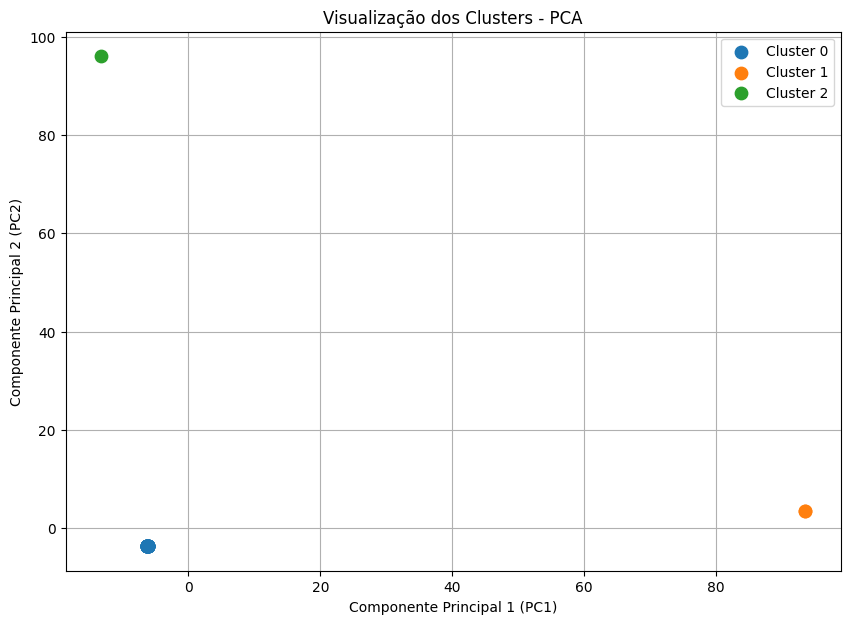

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for cluster in sorted(df_resultado['CLUSTER'].unique()):

    dados_cluster = df_resultado[
        df_resultado['CLUSTER'] == cluster
    ]

    plt.scatter(
        dados_cluster['PC1'],
        dados_cluster['PC2'],
        label=f'Cluster {cluster}',
        s=80
    )

plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.title('Visualização dos Clusters - PCA')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
componentes = pd.DataFrame(
    pca.components_,
    columns=X_features.columns,
    index=['PC1', 'PC2']
)

print(componentes.round(4))

     TOTAL_GASTO  QTD_NOTAS  VALOR_MEDIO_NOTA  DESVIO_MENSAL  \
PC1        -0.00      -0.00             -0.01          -0.01   
PC2         0.00       0.00              0.00          -0.01   

     CONSULTORIA_CONTABIL  CONSULTORIA_JURIDICA  DIVULGACAO_MARKETING  \
PC1                 -0.00                 -0.01                 -0.00   
PC2                 -0.00                 -0.01                 -0.01   

     LOCACAO_ALUGUEIS  OUTROS  
PC1              1.00   -0.07  
PC2              0.07    1.00  


In [ ]:
print("Variância explicada por componente:")

for i, valor in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {valor:.4%}")

print(
    f"Total dos 2 componentes: "
    f"{pca.explained_variance_ratio_.sum():.4%}"
)

Variância explicada por componente:
PC1: 65.6409%
PC2: 33.7025%
Total dos 2 componentes: 99.3434%


In [ ]:
print("FEATURES UTILIZADAS:")
for coluna in X_features.columns:
    print("-", coluna)

FEATURES UTILIZADAS:
- TOTAL_GASTO
- QTD_NOTAS
- VALOR_MEDIO_NOTA
- DESVIO_MENSAL
- CONSULTORIA_CONTABIL
- CONSULTORIA_JURIDICA
- DIVULGACAO_MARKETING
- LOCACAO_ALUGUEIS
- OUTROS


In [ ]:
print("\nFORMATO:")
print(df_consolidado.shape)


FORMATO:
(31, 10)


In [ ]:
print("\nESTATÍSTICAS:")
print(df_consolidado.describe().T.round(2))


ESTATÍSTICAS:
                      count      mean      std     min      25%       50%  \
TOTAL_GASTO           31.00 108982.56 58259.72 4666.00 58000.00 126600.00   
QTD_NOTAS             31.00     16.81     8.55    1.00     9.50     20.00   
VALOR_MEDIO_NOTA      31.00   6394.60   825.27 4050.00  6087.92   6843.75   
DESVIO_MENSAL         31.00    647.44   854.14    0.00     0.00    184.36   
CONSULTORIA_CONTABIL  31.00      0.35     1.96    0.00     0.00      0.00   
CONSULTORIA_JURIDICA  31.00     52.54    47.30    0.00     2.60     48.86   
DIVULGACAO_MARKETING  31.00     37.43    45.26    0.00     0.00      0.00   
LOCACAO_ALUGUEIS      31.00      6.45    24.97    0.00     0.00      0.00   
OUTROS                31.00      3.23    17.96    0.00     0.00      0.00   

                           75%       max  
TOTAL_GASTO          163000.00 175000.00  
QTD_NOTAS                24.00     25.00  
VALOR_MEDIO_NOTA       7000.00   7000.00  
DESVIO_MENSAL          1046.64   2998.50  

In [ ]:
df_outliers = df_resultado[
    ['PARLAMENTAR', 'CLUSTER', 'DIST_CENTROIDE']
].sort_values(
    'DIST_CENTROIDE',
    ascending=False
)

display(df_outliers)

,PARLAMENTAR,CLUSTER,DIST_CENTROIDE
20,MARCOS ALEXANDRE DE OLIVEIRA SOBREIRA,0,10.59
28,RENATO MARTINS LEITÃO,0,2.97
30,VALDIR JOSÉ DOWSLEY,0,2.78
1,BRUNO FARIAS DE PAIVA,0,2.74
26,PAULO TARCÍSIO PESSOA JARDIM,0,2.08
25,MOISÉS FIGUEIREDO FEREIRA DE LIMA,0,2.03
8,FABÍOLA LEVI MEIRA,0,1.85
18,KELSON DE ASSIS CHAVES,0,1.74
19,MARCELO PEREIRA DE CASTRO,0,1.74
16,JOÃO CARVALHO DA COSTA SOBRINHO,0,1.70


In [ ]:
Q1 = df_resultado['DIST_CENTROIDE'].quantile(0.25)
Q3 = df_resultado['DIST_CENTROIDE'].quantile(0.75)

IQR = Q3 - Q1

limite_outlier = Q3 + 1.5 * IQR

df_resultado['POTENCIAL_ATIPICO'] = (
    df_resultado['DIST_CENTROIDE'] > limite_outlier
)

In [ ]:
df_resultado[
    df_resultado['POTENCIAL_ATIPICO']
][
    ['PARLAMENTAR', 'CLUSTER', 'DIST_CENTROIDE']
]

,PARLAMENTAR,CLUSTER,DIST_CENTROIDE
1,BRUNO FARIAS DE PAIVA,0,2.74
20,MARCOS ALEXANDRE DE OLIVEIRA SOBREIRA,0,10.59
28,RENATO MARTINS LEITÃO,0,2.97
30,VALDIR JOSÉ DOWSLEY,0,2.78


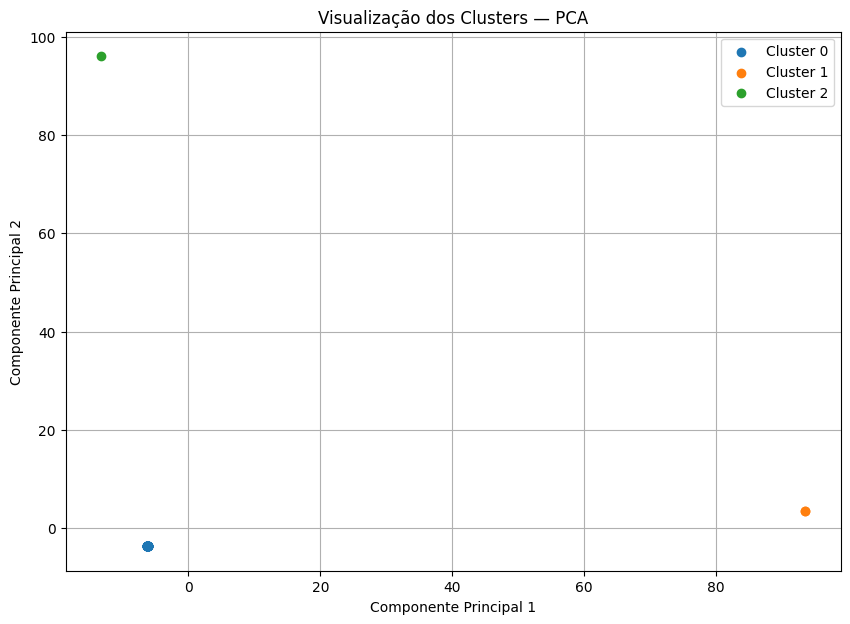

In [ ]:
plt.figure(figsize=(10, 7))

for cluster in sorted(df_resultado['CLUSTER'].unique()):
    dados = df_resultado[df_resultado['CLUSTER'] == cluster]

    plt.scatter(
        dados['PC1'],
        dados['PC2'],
        label=f'Cluster {cluster}'
    )

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Visualização dos Clusters — PCA')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
resultado_final = df_resultado[
    [
        'PARLAMENTAR',
        'CLUSTER',
        'DIST_CENTROIDE',
        'POTENCIAL_ATIPICO'
    ]
].sort_values(['CLUSTER', 'DIST_CENTROIDE'])

display(resultado_final)

,PARLAMENTAR,CLUSTER,DIST_CENTROIDE,POTENCIAL_ATIPICO
3,CARLOS HENRIQUE DA COSTA SANTOS,0,0.60,False
10,FRANCISCO HENRIQUE DA SILVA,0,0.82,False
29,RONIVON RAMALHO DINIZ,0,0.94,False
11,GABRIEL CARVALHO CÂMARA,0,1.04,False
2,CARLOS GUSTAVO GOMES DE OLIVEIRA,0,1.10,False
12,IVES ROCHA LEITÃO,0,1.17,False
9,FERNANDO PAULO CARRILHO MILANÊS NETO,0,1.17,False
6,ELIZA VIRGÍNIA DE SOUZA FERNANDES,0,1.21,False
4,DAMÁSIO FRANCA SEGUNDO NETO,0,1.23,False
24,MARMUTHE DE SOUZA CAVALCANTI,0,1.32,False


In [ ]:
resultado_final.to_csv(
    'resultado_clusters_cmjp.csv',
    index=False
)

In [ ]:
df_outliers = df_resultado[
    ['PARLAMENTAR', 'CLUSTER', 'DIST_CENTROIDE']
].sort_values(
    'DIST_CENTROIDE',
    ascending=False
)

display(df_outliers)

,PARLAMENTAR,CLUSTER,DIST_CENTROIDE
20,MARCOS ALEXANDRE DE OLIVEIRA SOBREIRA,0,10.59
28,RENATO MARTINS LEITÃO,0,2.97
30,VALDIR JOSÉ DOWSLEY,0,2.78
1,BRUNO FARIAS DE PAIVA,0,2.74
26,PAULO TARCÍSIO PESSOA JARDIM,0,2.08
25,MOISÉS FIGUEIREDO FEREIRA DE LIMA,0,2.03
8,FABÍOLA LEVI MEIRA,0,1.85
18,KELSON DE ASSIS CHAVES,0,1.74
19,MARCELO PEREIRA DE CASTRO,0,1.74
16,JOÃO CARVALHO DA COSTA SOBRINHO,0,1.70


In [ ]:
Q1 = df_resultado['DIST_CENTROIDE'].quantile(0.25)
Q3 = df_resultado['DIST_CENTROIDE'].quantile(0.75)

IQR = Q3 - Q1

limite = Q3 + 1.5 * IQR

df_resultado['POTENCIAL_ATIPICO'] = (
    df_resultado['DIST_CENTROIDE'] > limite
)

print("Limite:", limite)

display(
    df_resultado[
        df_resultado['POTENCIAL_ATIPICO']
    ][
        ['PARLAMENTAR', 'CLUSTER', 'DIST_CENTROIDE']
    ]
)

Limite: 2.5688913262676296


,PARLAMENTAR,CLUSTER,DIST_CENTROIDE
1,BRUNO FARIAS DE PAIVA,0,2.74
20,MARCOS ALEXANDRE DE OLIVEIRA SOBREIRA,0,10.59
28,RENATO MARTINS LEITÃO,0,2.97
30,VALDIR JOSÉ DOWSLEY,0,2.78
